# VQE: from circuit to a measured answer

### Conference demonstration

Start with a **two-qubit example** in which the most frequent measurement is the answer. Then look at a larger constrained problem and its full circuit. The larger example shows why a short VQE run may leave a broad, imperfect measurement distribution.

The saved figures and outputs can be presented without rerunning the notebook. Both examples use a local simulator.

## 1. A problem that fits on two qubits

Let $a,b\in\{0,1\}$. We want to maximize

$$f(a,b)=3a+2b-4ab.$$

The interaction term $ab$ gives the entangling gate a role. Here **qubit $q_0$ represents $a$** and **qubit $q_1$ represents $b$**. Qiskit displays a measurement as $q_1q_0$, so displayed `01` means $a=1,b=0$.

In [1]:
# The two-bit model becomes an Ising Hamiltonian for SamplingVQE.
import matplotlib.pyplot as plt
from qiskit.circuit.library import n_local
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit_optimization import QuadraticProgram

small_problem = QuadraticProgram("Two-qubit VQE")
small_problem.binary_var("a")
small_problem.binary_var("b")
small_problem.maximize(linear={"a": 3, "b": 2}, quadratic={("a", "b"): -4})
cost_operator, offset = small_problem.to_ising()
small_ansatz = n_local(2, "ry", "cz", reps=2, entanglement="full")

In [2]:
print(small_problem.prettyprint())

Problem name: Two-qubit VQE

Maximize
  -4*a*b + 3*a + 2*b

Subject to
  No constraints

  Binary variables (2)
    a b



## 2. Read the circuit from left to right

| Block | Meaning |
|---|---|
| $|00\rangle$ | Known starting state. |
| $R_y(\theta)$ | Adjustable rotations create a trial state. |
| $CZ$ | Entangles the qubits, allowing the state to represent the $ab$ interaction. |
| Repeated layer | More angles give the optimizer more possible states. |
| Measurement | Repeated runs produce a distribution of `00`, `01`, `10`, and `11`. |

The classical optimizer uses the measured distribution to estimate the cost, changes the angles, and runs the circuit again. That feedback step happens **between** quantum circuit executions.

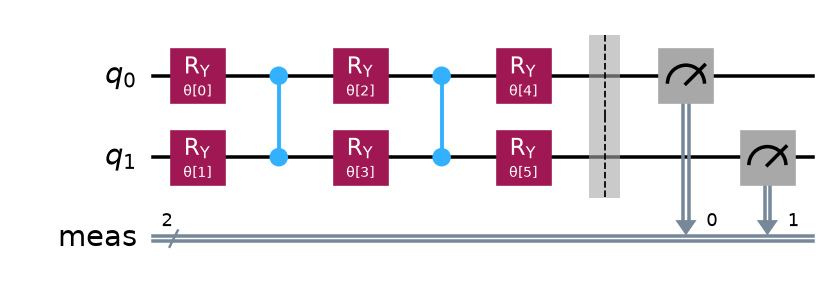

In [3]:
# This is the actual two-qubit ansatz, followed by measurement.
measured_small_circuit = small_ansatz.copy()
measured_small_circuit.measure_all()
measured_small_circuit.draw(output="mpl", scale=1.1)

## 3. Let VQE tune the angles

We use 1,024 simulated measurements per energy estimate and 20 optimizer evaluations. `SamplingVQE` trains the circuit to lower the Ising cost. Afterward, we read the **most frequent measured bitstring directly**; there is no scan for a better result among rare samples in this main demonstration.

In [4]:
# Save the estimated energy at each optimizer step.
SMALL_SEED, SMALL_SHOTS = 1234, 1024
algorithm_globals.random_seed = SMALL_SEED
small_energy = []

def record_small_energy(evaluation, parameters, mean, metadata):
    small_energy.append(float(mean))

small_vqe = SamplingVQE(
    sampler=StatevectorSampler(default_shots=SMALL_SHOTS, seed=SMALL_SEED),
    ansatz=small_ansatz,
    optimizer=COBYLA(maxiter=20),
    callback=record_small_energy,
)
small_result = small_vqe.compute_minimum_eigenvalue(cost_operator)
small_distribution = small_result.eigenstate
most_frequent = max(small_distribution, key=small_distribution.get)
a, b = int(most_frequent[1]), int(most_frequent[0])
print(f"Most frequent measurement (q1q0): {most_frequent}")
print(f"Decoded result: a={a}, b={b}; objective f={small_problem.objective.evaluate([a, b]):g}")

Most frequent measurement (q1q0): 01
Decoded result: a=1, b=0; objective f=3


01: 984 of 1024 shots


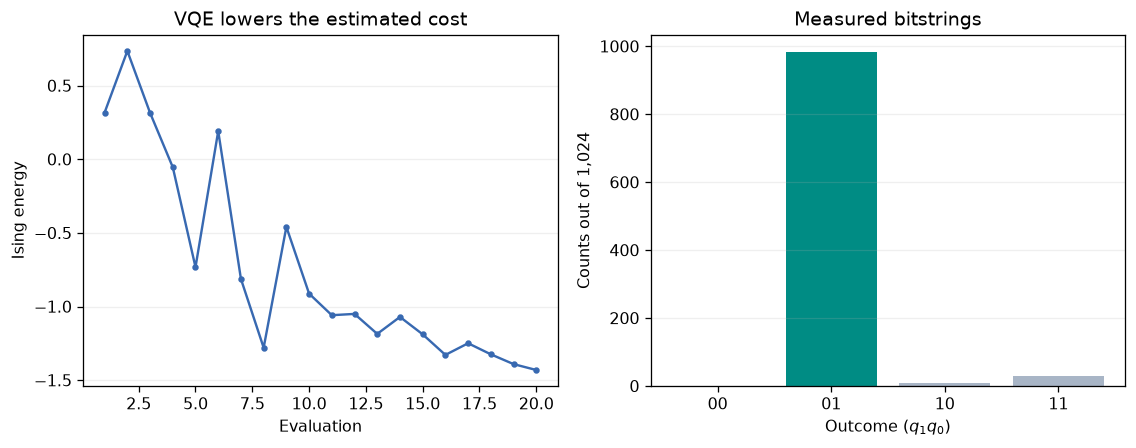

In [5]:
# Left: VQE training. Right: every possible two-bit measurement outcome.
outcomes = ["00", "01", "10", "11"]
counts = [round(SMALL_SHOTS * small_distribution.get(bits, 0)) for bits in outcomes]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(range(1, len(small_energy) + 1), small_energy, color="#3869b1", marker="o", ms=3)
ax1.set(title="VQE lowers the estimated cost", xlabel="Evaluation", ylabel="Ising energy")
ax2.bar(outcomes, counts, color=["#a8b5c6" if bits != most_frequent else "#008c84" for bits in outcomes])
ax2.set(title="Measured bitstrings", xlabel="Outcome ($q_1q_0$)", ylabel="Counts out of 1,024")
for axis in (ax1, ax2):
    axis.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()
print(f"{most_frequent}: {round(SMALL_SHOTS * small_distribution[most_frequent])} of {SMALL_SHOTS} shots")

### Convert the tallest bar into the result

In the saved run, `01` appears **984 of 1,024 times**. Qiskit writes $q_1q_0$, so `01` means $q_0=1\Rightarrow a=1$ and $q_1=0\Rightarrow b=0$. Substituting those measured bits gives $f(1,0)=3(1)+2(0)-4(1)(0)=\mathbf{3}$.

The histogram itself supports the conclusion: the answer is the **dominant measurement**, not a rare sample found by ranking many candidates. Counts can vary slightly on rerun. This small example teaches the VQE mechanism; it is not a claim of speed advantage over classical computing.

## 4. Real IBM Quantum device

The angles above were **trained on the local simulator**. For this first hardware test, we keep those angles fixed, transpile the measured two-qubit circuit for an operational IBM backend, and send **one 1,024-shot Sampler job**. This tests how the same prepared state measures on real hardware; it is not a full VQE optimization loop on the device.

The connection pattern follows the Grover notebook's idea: choose a real backend, transpile for it, submit, then inspect counts. This notebook uses the installed **IBM Runtime `SamplerV2`** API. The token is read from `ibmq_key` in the repository's `.env` file and is never displayed or saved in the notebook.

The job below has already been submitted. The cell defaults to **retrieving that job**, so rerunning the notebook will not use more QPU time. Set `SUBMIT_NEW_JOB = True` only when you intentionally want another device run.

In [ ]:
# Keep the token in .env; only the public job ID is stored in this notebook.
from pathlib import Path
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

env_file = next(parent / '.env' for parent in (Path.cwd(), *Path.cwd().parents)
                if (parent / '.env').is_file())
key = next(value.strip().strip('"').strip("'")
           for line in env_file.read_text().splitlines()
           for name, sep, value in [line.partition('=')]
           if sep and name.strip() == 'ibmq_key')
service = QiskitRuntimeService(channel='ibm_quantum_platform', token=key, instance='auto')

IBM_JOB_ID = 'dasegqjojkfs738p8fng'
SUBMIT_NEW_JOB = False
if SUBMIT_NEW_JOB:
    backend = service.least_busy(min_num_qubits=2, operational=True, simulator=False)
    measured_circuit = small_ansatz.assign_parameters(small_result.optimal_point)
    measured_circuit.measure_all()
    pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=3)
    isa_circuit = pass_manager.run(measured_circuit)
    job = SamplerV2(mode=backend).run([isa_circuit], shots=SMALL_SHOTS)
    IBM_JOB_ID = job.job_id()  # Save this ID before running another job.
else:
    job = service.job(IBM_JOB_ID)

print(f'Backend: {job.backend().name}; job ID: {IBM_JOB_ID}; status: {job.status()}')

Backend: ibm_marrakesh; job ID: dasegqjojkfs738p8fng; status: DONE


Hardware counts: {'01': 986, '11': 18, '10': 13, '00': 7}
Hardware mode: 01 (986 of 1024 shots)


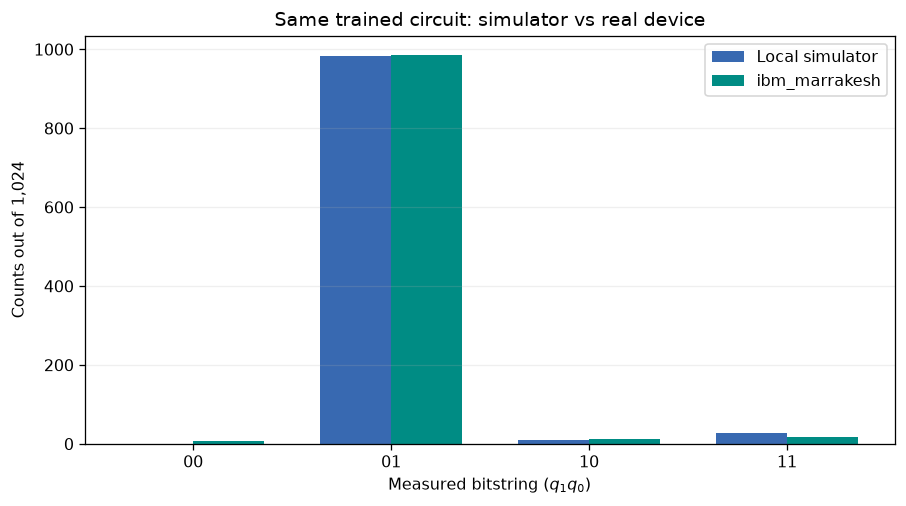

In [7]:
# Sampler returns measured bits as counts. Compare the same four outcomes.
hardware_counts = job.result()[0].data.meas.get_counts()
hardware_mode = max(hardware_counts, key=hardware_counts.get)
print('Hardware counts:', hardware_counts)
print(f'Hardware mode: {hardware_mode} ({hardware_counts[hardware_mode]} of {sum(hardware_counts.values())} shots)')

outcomes = ['00', '01', '10', '11']
sim_counts = [round(SMALL_SHOTS * small_distribution.get(bits, 0)) for bits in outcomes]
device_counts = [hardware_counts.get(bits, 0) for bits in outcomes]
fig, ax = plt.subplots(figsize=(8, 4.5))
positions = list(range(4))
ax.bar([x - 0.18 for x in positions], sim_counts, width=0.36, label='Local simulator', color='#3869b1')
ax.bar([x + 0.18 for x in positions], device_counts, width=0.36, label=job.backend().name, color='#008c84')
ax.set(xticks=positions, xticklabels=outcomes, xlabel='Measured bitstring ($q_1q_0$)',
       ylabel='Counts out of 1,024', title='Same trained circuit: simulator vs real device')
ax.legend()
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

### What the hardware run shows

On **ibm_marrakesh**, `01` was measured **986 of 1,024 times**. It still decodes to $a=1$, $b=0$, so the original objective is $f=3$. The local run recorded **984 of 1,024** for `01`. Small differences between these two single-shot-count experiments can come from sampling variation and device noise; this comparison alone does not estimate hardware fidelity or show quantum advantage.


## 5. Larger constrained example

Now scale the same idea to three binary choices $x_1,x_2,x_3$ and two integers $x_4,x_5\in\{0,\ldots,10\}$:

$$\max\;x_1^2+x_2-3x_3+5x_4-x_5,\qquad x_4+x_5\ge15.$$

Encoding the integers and constraint gives a **14-qubit** cost Hamiltonian. This example is useful for showing the full circuit and the effect of harder encodings, but its 100-evaluation run does **not** concentrate measurements on its reported answer as clearly as the two-qubit example.

In [8]:
# Build the larger model and its 14-bit QUBO encoding.
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

problem = QuadraticProgram("Larger VQE example")
for name in ("x1", "x2", "x3"):
    problem.binary_var(name)
for name in ("x4", "x5"):
    problem.integer_var(lowerbound=0, upperbound=10, name=name)
problem.maximize(linear={"x2": 1, "x3": -3, "x4": 5, "x5": -1},
                 quadratic={("x1", "x1"): 1})
problem.linear_constraint(linear={"x4": 1, "x5": 1}, sense=">=", rhs=15)
qubo = QuadraticProgramToQubo().convert(problem)
ansatz = n_local(qubo.get_num_vars(), "ry", "cz", reps=3, entanglement="full")
print(f"{problem.get_num_vars()} model variables → {ansatz.num_qubits} qubits")

5 model variables → 14 qubits


In [9]:
# Run the larger VQE example. Here Qiskit decodes and ranks feasible
# measured candidates, which is different from reading the histogram mode.
SEED, SHOTS = 1234, 1024
algorithm_globals.random_seed = SEED
energy = []

def record_energy(evaluation, parameters, mean, metadata):
    energy.append(float(mean))

vqe = SamplingVQE(
    sampler=StatevectorSampler(default_shots=SHOTS, seed=SEED),
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=100),
    callback=record_energy,
)
result = MinimumEigenOptimizer(vqe).solve(problem)
print(result.prettyprint())

objective function value: 47.0
variable values: x1=1.0, x2=1.0, x3=0.0, x4=10.0, x5=5.0
status: SUCCESS


### Full optimized circuit

This is the complete circuit you added, with angles fixed at the values learned in the larger run. It shows the substantial gate depth and connectivity hidden by a simple VQE block diagram.



In [10]:
optimized = result.min_eigen_solver_result
circuit = optimized.optimal_circuit.assign_parameters(optimized.optimal_parameters)
circuit.decompose(reps=1).draw(output="mpl", fold=25, scale=1)


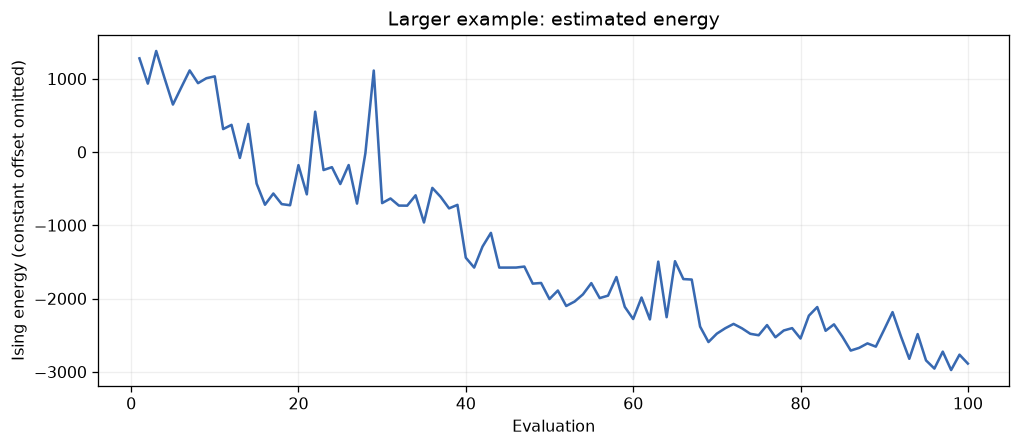

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(energy) + 1), energy, color="#3869b1", linewidth=1.6)
ax.set(title="Larger example: estimated energy", xlabel="Evaluation",
       ylabel="Ising energy (constant offset omitted)")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

### How to describe the larger result honestly

`MinimumEigenOptimizer` decodes the bitstrings **actually sampled** and selects the best feasible original assignment among them. It does not enumerate every possible bitstring. In this short 14-qubit run, the returned assignment is rare in the measurement distribution, so its printed objective alone should **not** be presented as evidence that the circuit strongly learned that answer.

For the main conference explanation, use the two-qubit histogram above: there, the quantum circuit's dominant output directly gives the reported result. The larger circuit shows what becomes harder when integers and constraints are encoded.